In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph, add_metpy_logo
from metpy.units import units
# from metpy.testing import assert_almost_equal, assert_array_almost_equal, assert_nan
import os
import sys
from pathlib import Path
import xarray as xr
# import pyCRMtools.legacy.thermolib as thermo
# import pyCRMtools.legacy.arpsmodule as arps
# sys.path.append('/Users/dawson29/Projects/plotsnd/')
# import plotsnd
from io import StringIO
# from pyCM1 import read as cm1read
# import sharppy
# import sharppy.sharptab.profile as profile
# import sharppy.sharptab.interp as interp
# import sharppy.sharptab.winds as winds
# import sharppy.sharptab.utils as utils
# import sharppy.sharptab.params as params
# import sharppy.sharptab.thermo as sthermo
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
###########################################

# Change default to be better for skew-T
plt.rcParams['figure.figsize'] = (9, 9)

# Units for hodograph (m/s or knots)
hodo_units = 'm/s'

# Set global font size for axes and colorbar labels, etc.
# font = {'size': 20}
# matplotlib.rc('font', **font)
# matplotlib.rc('axes.titlesize:20')

###########################################

In [3]:
# Function definitions
def write_sounding(z, theta, qv, u, v, psfc, thetasfc, qvsfc, output_path):
    """
    Writes the sounding data to a file.

    Parameters
    ----------
    output_path : str
        The path to the output file.

    Returns
    -------
    None
    """

    # Write the sounding data to a file. The following is stolen from old code in plotsnd.py
    # originally inherited from Lou Wicker.
    # TODO: Can probably clean up later. Not sure writing
    # everything out, reading it back in and then inserting the header is necessary.
    # Can probably use pandas.to_csv() or something similar to write the data out directly.

    fmtstr = '%8.8f'

    np.savetxt(
        output_path,
        np.transpose(
            (z,
             theta,
             qv,
             u,
             v)),
        fmt=fmtstr)
    with Path(output_path).open('r') as f:
        text = f.read()
    f.close()   # Don't need this I don't think
    with Path(output_path).open('w') as f:
        # str = "%8.2f    %8.2f   %8.2f\n" % (self.psfc, self.tsfc, 1000.*self.qsfc)
        str = (fmtstr + "    " + fmtstr + "   " + fmtstr +
               "\n") % (psfc,
                        thetasfc,
                        qvsfc)
        f.write(str)
        f.write(text)
    f.close()   # Don't need this I don't think




def read_CM1_netCDF(dirname, prefix="cm1out", one_time_per_file=True, merge_times=False):
    glob_pattern = "_[0-9]*.nc"
    if one_time_per_file:
        cm1_filename = prefix + glob_pattern
    else:
        cm1_filename = prefix + ".nc"

    if one_time_per_file:
        if merge_times:
            cm1_paths = Path(dirname) / cm1_filename
            # print(cm1_paths)
            # Sort the paths
            # cm1_paths = sorted(cm1_paths)
            cm1_ds = xr.open_mfdataset(str(cm1_paths), decode_cf=False)
            return [cm1_paths], [cm1_ds]
        else:
            cm1_paths = list(Path(dirname).glob(cm1_filename))
            # Sort the paths
            cm1_paths = sorted(cm1_paths)
            cm1_ds_list = [xr.open_dataset(cm1_path, decode_cf=False) for cm1_path in cm1_paths]
            return cm1_paths, cm1_ds_list
    else:
        cm1_path = Path(dirname) / cm1_filename
        cm1_ds = xr.open_dataset(cm1_path, decode_cf=False)
        return [cm1_path], [cm1_ds]


def plot_hodo(fig, ax, z, u, v, ls='-', lw=4, alpha=0.5, component_range=15.):
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    h = Hodograph(ax, component_range=component_range)

    # Add two separate grid increments for a cooler look. This also
    # helps to increase readability
    h.add_grid(increment=20, ls='-', lw=1.5, alpha=0.5)
    h.add_grid(increment=10, ls='--', lw=1, alpha=0.2)

    # The next few steps makes for a clean hodograph inset, removing the
    # tick marks, tick labels, and axis labels
    h.ax.set_box_aspect(1)
    h.ax.set_yticklabels([])
    h.ax.set_xticklabels([])
    h.ax.set_xticks([])
    h.ax.set_yticks([])
    h.ax.set_xlabel(' ')
    h.ax.set_ylabel(' ')

    # Here we can add a simple Python for loop that adds tick marks
    # to the inside of the hodograph plot to increase readability!
    plt.xticks(np.arange(0, 0, 1))
    plt.yticks(np.arange(0, 0, 1))
    for i in range(10, 120, 10):
        h.ax.annotate(str(i), (i, 0), xytext=(0, 2), textcoords='offset pixels',
                      clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
    for i in range(10, 120, 10):
        h.ax.annotate(str(i), (0, i), xytext=(0, 2), textcoords='offset pixels',
                      clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)

    # plot the hodograph itself, using plot_colormapped, colored
    # by height
    # h.plot_colormapped(u[:z_12_index], v[:z_12_index], c=z[:z_12_index], linewidth=6, label='0-12km WIND')
    z_100m_index = np.where(z.magnitude >= 100.)[0][0] + 1
    z_250m_index = np.where(z.magnitude >= 250.)[0][0] + 1
    z_1km_index = np.where(z.magnitude >= 1000.)[0][0] + 1
    z_3km_index = np.where(z.magnitude >= 3000.)[0][0] + 1
    z_12km_index = np.where(z.magnitude >= 12000.)[0][0] + 1
    h.plot(u[:z_100m_index], v[:z_100m_index], c='green', linestyle=ls, linewidth=lw, alpha=alpha, label='0-1 km WIND')
    h.plot(u[z_100m_index-1:z_250m_index], v[z_100m_index-1:z_250m_index], c='magenta', linestyle=ls, linewidth=lw, alpha=alpha, label='0-1 km WIND')
    h.plot(u[z_250m_index-1:z_1km_index], v[z_250m_index-1:z_1km_index], c='purple', linestyle=ls, linewidth=lw, alpha=alpha, label='0-1 km WIND')
    h.plot(u[z_1km_index-1:z_3km_index], v[z_1km_index-1:z_3km_index], c='red', linestyle=ls, linewidth=lw, alpha=alpha, label='1-3 km WIND')
    h.plot(u[z_3km_index-1:z_12km_index], v[z_3km_index-1:z_12km_index], c='blue', linestyle=ls, linewidth=lw, alpha=alpha, label='3-12 km WIND')

    return fig, ax


In [4]:
# Set up simulation directory and files to read
simulation_basedir = '/Users/dawson29/Projects/ICECHIP/simulations/CM1/100m_singlecol'
# simulation_basedir = '/Users/dawson29/Projects/NSF_CAREER/simulations/CM1r21/1km_hodo_drag_specified/'
# simulation_name = '1kmV2torcomp_new_NSSL3M_NDGEO_test_seed_656948879' # '1kmV2torcomp_new_NSSL3M_NDGEO_test_seed_656948879/' # '1kmV2torcomp_new_NSSL3M_NDGEO_test_seed_2115096077' # '1kmV2torcomp_new_NSSL3M_NDGEO_test_seed_2038197332/'
# sim_prefix = 'near-field-nontor-EF2+'
# sim_suffix = 'drag' # 'drag_test2'
# added_wind_str = 'um10_vm10'
# seed = 13
# simulation_name = f'{sim_prefix}_nostorm_{added_wind_str}_{sim_suffix}_seed_{seed:d}'
simulation_name = 'IOP12_06062025_21z_HRRR_u10v-5_NS_singlecol'
# simulation_name = f'{sim_prefix}_{added_wind_str}_{sim_suffix}_seed_{seed:d}'
simulation_dir = Path(simulation_basedir) / simulation_name

# For dumping out sounding to file
sounding_dir = '/Users/dawson29/Projects/ICECHIP/soundings/'
sounding_filename = f'IOP12_06062025_21z_HRRR_fmod.cm1snd'
sounding_path = os.path.join(sounding_dir, sounding_filename)

cm1_paths, cm1_ds_list = read_CM1_netCDF(simulation_dir, prefix="cm1out", one_time_per_file=True,
                                         merge_times=True)
cm1_ds = cm1_ds_list[0]

plot_dir = os.path.join(simulation_basedir, 'plots')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

In [5]:
cm1_ds

<xarray.Dataset> Size: 557kB
Dimensions:    (time: 25, one: 1, yh: 1, xh: 1, zh: 80, xf: 2, yf: 2, zf: 81)
Coordinates:
  * time       (time) float32 100B 0.0 3.6e+03 7.2e+03 ... 8.28e+04 8.64e+04
  * xh         (xh) float32 4B 0.05
  * xf         (xf) float32 8B 0.0 0.1
  * yh         (yh) float32 4B 0.05
  * yf         (yf) float32 8B 0.0 0.1
  * zh         (zh) float32 320B 0.005 0.01804 0.03715 ... 18.79 19.27 19.76
  * zf         (zf) float32 324B 0.0 0.01 0.02608 0.04823 ... 19.03 19.51 20.0
Dimensions without coordinates: one
Data variables: (12/91)
    f_cor      (time, one) float32 100B dask.array<chunksize=(1, 1), meta=np.ndarray>
    ztop       (time, one) float32 100B dask.array<chunksize=(1, 1), meta=np.ndarray>
    umove      (time) float32 100B dask.array<chunksize=(1,), meta=np.ndarray>
    vmove      (time) float32 100B dask.array<chunksize=(1,), meta=np.ndarray>
    rain       (time, yh, xh) float32 100B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    prate      (time, yh, xh) float32 100B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    ...         ...
    wb_vidiff  (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
    wb_hturb   (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
    wb_vturb   (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
    wb_pgrad   (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
    wb_rdamp   (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
    wb_buoy    (time, zf, yh, xh) float32 8kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>
Attributes: (12/71)
    CM1 version:    cm1r21.0
    Conventions:    CF-1.7
    missing_value:  -999999.9
    x_units:        km
    x_label:        x
    y_units:        km
    ...             ...
    cgt1:           1.883619
    cgt2:           -1.2689224
    cgt3:           0.38530347
    dgt1:           2.0219567
    dgt2:           -3.0504992
    dgt3:           1.0285425

0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.19999999999999996
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8


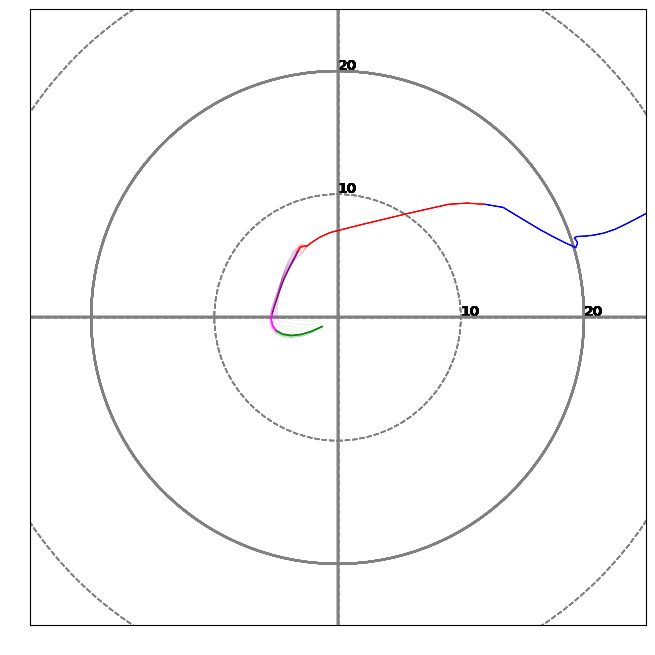

In [6]:
# times to plot
# times_to_plot = [0., 1800., 3600., 5400., 7200., 9000., 10800., 12600., 14400.]
times_to_plot = np.arange(0, 25) * 3600.
# times_to_plot = np.arange(0, 49) * 3600.
# times_to_plot = np.arange(0, 49) * 300.
# times_to_plot = [12600., 14400.]
# times_to_plot = [0., 1800., 3600., 5400., 7200., 9000.]
# Plot sounding in SE corner
# xsnd = 198
# ysnd = 198
# For 1-D column run, obviously it's just the single x, y point
xsnd = 1
ysnd = 1


fig, ax = plt.subplots(figsize=(8, 8))

for t, time in enumerate(times_to_plot):

    alpha_step = 0.1
    alpha_min = 0.1
    alpha_max = 0.8

    t_fac = len(times_to_plot) - t - 1

    ls = '-'
    if time == times_to_plot[-1]:
        lw = 1.0
    else:
        lw = 0.5
    alpha = max(alpha_min, alpha_max - t_fac * alpha_step)
    print(alpha)

    cm1_1t_ds = cm1_ds.sel(time=time)

    zsnd = (cm1_1t_ds['zh'].to_numpy() * units.kilometers).to(units.meters)
    umove = cm1_1t_ds['umove'].to_numpy()
    vmove = cm1_1t_ds['vmove'].to_numpy()
    usnd = (cm1_1t_ds['uinterp'].sel(xh=xsnd, yh=ysnd, method='nearest').to_numpy() + umove) * units('m/s')
    vsnd = (cm1_1t_ds['vinterp'].sel(xh=xsnd, yh=ysnd, method='nearest').to_numpy() + vmove) * units('m/s')

    plot_hodo(fig, ax, zsnd, usnd, vsnd, ls=ls, lw=lw, alpha=alpha, component_range=25.)

plot_dir = os.path.join(simulation_basedir, 'plots')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

plot_filename = f"{simulation_name}_hodo_seq.png"
plot_path = os.path.join(plot_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')

In [7]:
# times to plot
# times_to_plot = [0., 1800., 3600., 5400., 7200., 9000., 10800., 12600., 14400.]
times_to_plot = np.arange(0, 25) * 3600.
# times_to_plot = np.arange(0, 49) * 3600.
# times_to_plot = np.arange(0, 49) * 300.
# times_to_plot = [12600., 14400.]
# times_to_plot = [0., 1800., 3600., 5400., 7200., 9000.]
# Plot sounding in SE corner
# xsnd = 198
# ysnd = 198
# For 1-D column run, obviously it's just the single x, y point
xsnd = 1
ysnd = 1

plot_dir = os.path.join(simulation_basedir, 'plots')
plot_dir = os.path.join(plot_dir, f'{simulation_name}_seq')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)


for t, time in enumerate(times_to_plot):

    fig, ax = plt.subplots(figsize=(8, 8))

    alpha_step = 0.1
    alpha_min = 0.1
    alpha_max = 0.8

    t_fac = len(times_to_plot) - t - 1

    ls = '-'
    lw = 1.0
    alpha = 1.0
    # if time == times_to_plot[-1]:
    #     lw = 1.0
    # else:
    #     lw = 0.5
    # alpha = max(alpha_min, alpha_max - t_fac * alpha_step)
    # print(alpha)

    cm1_1t_ds = cm1_ds.sel(time=time)

    zsnd = (cm1_1t_ds['zh'].to_numpy() * units.kilometers).to(units.meters)
    umove = cm1_1t_ds['umove'].to_numpy()
    vmove = cm1_1t_ds['vmove'].to_numpy()
    usnd = (cm1_1t_ds['uinterp'].sel(xh=xsnd, yh=ysnd, method='nearest').to_numpy() + umove) * units('m/s')
    vsnd = (cm1_1t_ds['vinterp'].sel(xh=xsnd, yh=ysnd, method='nearest').to_numpy() + vmove) * units('m/s')

    fig, ax = plot_hodo(fig, ax, zsnd, usnd, vsnd, ls=ls, lw=lw, alpha=alpha, component_range=25.)
    ax.set_xlim(-15., 35.)
    ax.set_ylim(-15., 35.)

    plot_filename = f"{simulation_name}_hodo_{t:03}.png"
    plot_path = os.path.join(plot_dir, plot_filename)

    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()

In [8]:
# Dump out sounding to file
# Get mean profiles of variables in dataset

cm1_mean_prof_ds = cm1_ds.mean(dim=['xf', 'yf', 'xh', 'yh'])
cm1_mean_prof_last_ds = cm1_mean_prof_ds.isel(time=-1)

psfc = cm1_mean_prof_last_ds['prs'][0] / 100.  # Get to hPa
qvsfc = cm1_mean_prof_last_ds['qv'][0] * 1000. # Get to g/kg
thetasfc = cm1_mean_prof_last_ds['th'][0]

z = cm1_mean_prof_last_ds['zh'] * 1000.   # Get to m
theta = cm1_mean_prof_last_ds['th']
qv = cm1_mean_prof_last_ds['qv'] * 1000.  # Get to g/kg
u = cm1_mean_prof_last_ds['u'] + cm1_mean_prof_last_ds['umove']
v = cm1_mean_prof_last_ds['v'] + cm1_mean_prof_last_ds['vmove']
write_sounding(z, theta, qv, u, v, psfc, thetasfc, qvsfc, sounding_path)